# Custom MASA Tabular Environments

This notebook introduces the local `Custom*` MASA-style tabular environments. For each environment it shows:

1. which settings can be tweaked and what they control,
2. what the environment represents,
3. one rendered frame from the default configuration.

The environments are registered through `experiments.utils.masa_tabular_envs` and can be created with `gymnasium.make(...)` or the helper `make_custom_masa_env(...)`.

In [1]:
from __future__ import annotations

import textwrap

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

import sys
sys.path.append('/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning')

import experiments.utils.masa_tabular_envs  # registers Custom* env IDs
from experiments.utils.masa_tabular_envs.factory import make_custom_masa_env


I0000 00:00:1780668032.472216  466423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780668032.554580  466423 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780668037.751558  466423 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Environment Catalogue

The catalogue below is intentionally explicit. It doubles as a quick reference for task YAML and `gym.make` kwargs.

In [2]:
ENV_CARDS = [
    {
        "id": "CustomFrozenLake-v0",
        "title": "FrozenLake",
        "explanation": "A Gymnasium-compatible FrozenLake tabular map where the agent moves from start to goal across frozen cells while avoiding holes. The local version exposes MASA-style transition matrices and labels while keeping Gymnasium dynamics and rendering.",
        "settings": {
            "desc": "Custom map as a list of strings using S=start, F=frozen, H=hole, and G=goal.",
            "map_name": "Built-in Gymnasium map name such as 4x4 or 8x8 when desc is not supplied.",
            "is_slippery": "Whether actions can slip to perpendicular directions.",
            "success_rate": "Probability that a slippery action moves in the intended direction.",
            "reward_schedule": "Rewards for goal, hole, and frozen cells, in Gymnasium's (G, H, F) order.",
            "render_window_size": "Optional square pixel size for RGB and human rendering; None keeps Gymnasium's default sizing.",
        },
        "example_kwargs": {"desc": ["SFFF", "FHFH", "FFFH", "HFFG"], "is_slippery": True},
    },
    {
        "id": "CustomBridgeCrossing-v0",
        "title": "Bridge Crossing",
        "explanation": "A 20x20 gridworld where the agent starts at the lower-left, tries to reach the goal band near the top, and must avoid lava regions around the bridge corridor.",
        "settings": {
            "slip_prob": "Probability that the intended action is replaced by one of the other actions.",
            "grid_size": "Width and height of the square grid. Defaults to the MASA 20x20 layout.",
            "start_state": "Discrete state index where each episode starts.",
            "goal_states": "State indices that terminate with reward 1.0.",
            "lava_states": "Unsafe terminal state indices that should be avoided.",
            "render_window_size": "Pixel size used for RGB and human rendering.",
        },
        "example_kwargs": {"slip_prob": 0.04},
    },
    {
        "id": "CustomBridgeCrossingV2-v0",
        "title": "Bridge Crossing V2",
        "explanation": "A second bridge-crossing map with a different lava geometry. It keeps the same navigation objective but changes which paths remain viable.",
        "settings": {
            "slip_prob": "Probability of stochastic action replacement.",
            "grid_size": "Square grid size used to interpret state indices.",
            "start_state": "Episode start state index.",
            "goal_states": "Rewarding terminal states near the top of the map.",
            "lava_states": "Unsafe terminal states for this V2 bridge layout.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"slip_prob": 0.04},
    },
    {
        "id": "CustomColourGridWorld-v0",
        "title": "Colour Grid World",
        "explanation": "A compact coloured gridworld with labelled coloured cells. The goal cell gives reward, while labelled colours can be used by constraints or specifications.",
        "settings": {
            "slip_prob": "Probability of executing a non-intended action.",
            "grid_size": "Width and height of the square grid.",
            "start_state": "State where the agent begins.",
            "goal_state": "Rewarding terminal state.",
            "blue_state": "State labelled blue; blue is treated as costly by the default cost function.",
            "green_state": "State labelled green.",
            "purple_state": "State labelled purple.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"slip_prob": 0.1},
    },
    {
        "id": "CustomColourBombGridWorld-v0",
        "title": "Colour Bomb Grid World",
        "explanation": "A 9x9 gridworld with coloured target regions, walls, and bomb cells. Bomb labels are unsafe/costly; coloured cells are task-relevant labels.",
        "settings": {
            "slip_prob": "Probability of stochastic action replacement.",
            "grid_size": "Square grid size.",
            "start_state": "Episode start state.",
            "start_states": "Optional set of possible start states.",
            "green_states/yellow_states/red_states/blue_states/pink_states": "Coloured labelled regions used as goals/specification labels.",
            "wall_states": "Blocking cells that prevent movement.",
            "bomb_states": "Unsafe cells labelled bomb by the default cost function.",
            "medic_states": "Optional safe states where slip can be suppressed in variants that use safe states.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"slip_prob": 0.1},
    },
    {
        "id": "CustomColourBombGridWorldV2-v0",
        "title": "Colour Bomb Grid World V2",
        "explanation": "A larger 15x15 colour-bomb map with multiple starts, walls, bombs, medic cells, and repeated target visits. Goal cells transition back to a random start rather than ending the episode.",
        "settings": {
            "slip_prob": "Probability of stochastic action replacement outside safe states.",
            "start_states": "Possible reset states and post-goal restart states.",
            "green_states/yellow_states/red_states/blue_states/pink_states": "Coloured goal/label regions.",
            "wall_states": "Blocking cells.",
            "bomb_states": "Unsafe/costly bomb cells.",
            "medic_states": "Safe cells where the transition builder treats movement as non-slippery.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"slip_prob": 0.1},
    },
    {
        "id": "CustomColourBombGridWorldV3-v0",
        "title": "Colour Bomb Grid World V3",
        "explanation": "A coloured-zone extension of V2. The state includes both grid position and an active colour zone, allowing richer task/specification dynamics.",
        "settings": {
            "slip_prob": "Probability of stochastic action replacement outside safe states.",
            "n_coloured_zones": "Number of colour-zone layers in the expanded state space.",
            "start_states": "Start/restart states before zone expansion.",
            "green_states/yellow_states/red_states/blue_states/pink_states": "Colour-labelled states before zone expansion.",
            "wall_states": "Blocking states before zone expansion.",
            "bomb_states": "Unsafe/costly states before zone expansion.",
            "medic_states": "Safe states before zone expansion.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"slip_prob": 0.1},
    },
    {
        "id": "CustomMediaStreaming-v0",
        "title": "Media Streaming",
        "explanation": "A tabular buffer-control problem. The agent chooses slow or fast streaming. Rewards penalize empty-buffer states.",
        "settings": {
            "fast_rate": "Input probability/rate when choosing the fast action.",
            "slow_rate": "Input probability/rate when choosing the slow action.",
            "out_rate": "Playback/drain probability of the buffer.",
            "buffer_size": "Number of discrete buffer levels.",
            "start_state": "Initial buffer level; defaults to half full.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"fast_rate": 0.9, "slow_rate": 0.1, "out_rate": 0.7},
    },
    {
        "id": "CustomMediaStreamingV2-v0",
        "title": "Media Streaming V2",
        "explanation": "A buffer-control variant that augments the state with a count of fast actions. Unsafe labels appear when fast usage exceeds a threshold.",
        "settings": {
            "fast_rate": "Input probability/rate for fast streaming.",
            "slow_rate": "Input probability/rate for slow streaming.",
            "out_rate": "Buffer drain probability.",
            "buffer_size": "Number of discrete buffer levels.",
            "episode_length": "Reference horizon used to derive the default fast-action threshold.",
            "c_threshold": "Maximum tolerated fast-action count before the unsafe label is reached.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"fast_rate": 0.9, "slow_rate": 0.1, "out_rate": 0.7},
    },
    {
        "id": "CustomMediaStreamingV3-v0",
        "title": "Media Streaming V3",
        "explanation": "A safety-abstraction variant with dictionary observations containing danger, buffer, and time. Actions change danger according to different transition probabilities.",
        "settings": {
            "buffer_size": "Number of buffer levels in observations and rendering.",
            "episode_length": "Maximum time index before termination.",
            "danger_threshold": "Danger level after which the unsafe label is reached.",
            "slow_danger_down_prob/slow_danger_up_prob": "Danger transition probabilities after the slow action.",
            "fast_danger_up_prob/fast_danger_down_prob": "Danger transition probabilities after the fast action.",
            "start_buffer/start_danger/start_time": "Initial buffer, danger, and time values.",
            "render_window_size": "Pixel size used for rendering.",
        },
        "example_kwargs": {"danger_threshold": 20},
    },
    {
        "id": "CustomMiniPacman-v0",
        "title": "Mini Pacman",
        "explanation": "A small tabular Pacman world. The agent moves through corridors, collects food for reward, and avoids a ghost controlled by a stochastic chase policy.",
        "settings": {
            "layout": "2D wall/free-cell map; 1 means wall and 0 means traversable.",
            "food": "Food coordinate as (x, y).",
            "ghost_rand_prob": "How random the ghost policy is. Lower values chase more greedily.",
            "agent_start": "Agent start coordinate as (x, y).",
            "agent_term": "Terminal coordinate as (x, y).",
            "agent_direction": "Initial agent facing direction.",
            "ghost_start": "Ghost start coordinate as (x, y).",
            "ghost_direction": "Initial ghost facing direction.",
            "pacman_hat/ghost_colors": "Rendering-only appearance settings.",
        },
        "example_kwargs": {"ghost_rand_prob": 0.6},
    },
    {
        "id": "CustomPacman-v0",
        "title": "Pacman",
        "explanation": "A larger tabular Pacman map with the same food, terminal, and ghost-chase structure as Mini Pacman, but with a much larger state space.",
        "settings": {
            "layout": "2D wall/free-cell map; 1 means wall and 0 means traversable.",
            "food": "Food coordinate as (x, y).",
            "ghost_rand_prob": "Ghost stochasticity; controls how deterministic the chase behavior is.",
            "agent_start": "Agent start coordinate as (x, y).",
            "agent_term": "Terminal coordinate as (x, y).",
            "agent_direction": "Initial agent facing direction.",
            "ghost_start": "Ghost start coordinate as (x, y).",
            "ghost_direction": "Initial ghost facing direction.",
            "pacman_hat/ghost_colors": "Rendering-only appearance settings.",
        },
        "example_kwargs": {"ghost_rand_prob": 0.6},
    },
]

len(ENV_CARDS)


11

## Render And Inspect

Run the next cell to inspect every environment. Each section creates a fresh environment with `render_mode="rgb_array"`, resets it once, and displays the initial frame.

## `CustomBridgeCrossing-v0` - Bridge Crossing

A 20x20 gridworld where the agent starts at the lower-left, tries to reach the goal band near the top, and must avoid lava regions around the bridge corridor.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability that the intended action is replaced by one of the other actions. |
| `grid_size` | Width and height of the square grid. Defaults to the MASA 20x20 layout. |
| `start_state` | Discrete state index where each episode starts. |
| `goal_states` | State indices that terminate with reward 1.0. |
| `lava_states` | Unsafe terminal state indices that should be avoided. |
| `render_window_size` | Pixel size used for RGB and human rendering. |

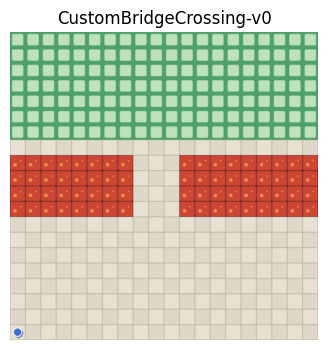

## `CustomBridgeCrossingV2-v0` - Bridge Crossing V2

A second bridge-crossing map with a different lava geometry. It keeps the same navigation objective but changes which paths remain viable.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability of stochastic action replacement. |
| `grid_size` | Square grid size used to interpret state indices. |
| `start_state` | Episode start state index. |
| `goal_states` | Rewarding terminal states near the top of the map. |
| `lava_states` | Unsafe terminal states for this V2 bridge layout. |
| `render_window_size` | Pixel size used for rendering. |

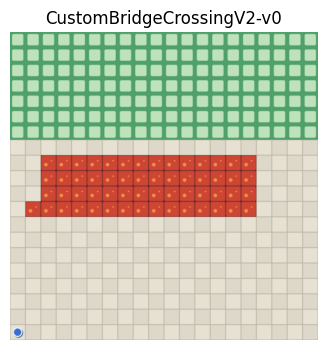

## `CustomColourGridWorld-v0` - Colour Grid World

A compact coloured gridworld with labelled coloured cells. The goal cell gives reward, while labelled colours can be used by constraints or specifications.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability of executing a non-intended action. |
| `grid_size` | Width and height of the square grid. |
| `start_state` | State where the agent begins. |
| `goal_state` | Rewarding terminal state. |
| `blue_state` | State labelled blue; blue is treated as costly by the default cost function. |
| `green_state` | State labelled green. |
| `purple_state` | State labelled purple. |
| `render_window_size` | Pixel size used for rendering. |

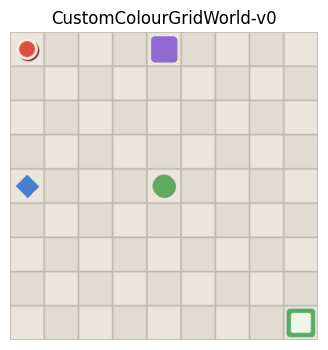

## `CustomColourBombGridWorld-v0` - Colour Bomb Grid World

A 9x9 gridworld with coloured target regions, walls, and bomb cells. Bomb labels are unsafe/costly; coloured cells are task-relevant labels.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability of stochastic action replacement. |
| `grid_size` | Square grid size. |
| `start_state` | Episode start state. |
| `start_states` | Optional set of possible start states. |
| `green_states/yellow_states/red_states/blue_states/pink_states` | Coloured labelled regions used as goals/specification labels. |
| `wall_states` | Blocking cells that prevent movement. |
| `bomb_states` | Unsafe cells labelled bomb by the default cost function. |
| `medic_states` | Optional safe states where slip can be suppressed in variants that use safe states. |
| `render_window_size` | Pixel size used for rendering. |

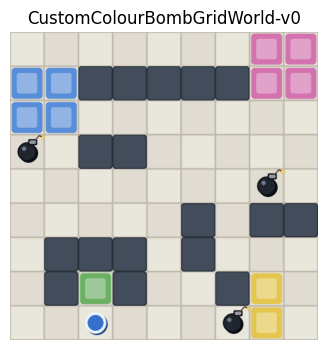

## `CustomColourBombGridWorldV2-v0` - Colour Bomb Grid World V2

A larger 15x15 colour-bomb map with multiple starts, walls, bombs, medic cells, and repeated target visits. Goal cells transition back to a random start rather than ending the episode.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability of stochastic action replacement outside safe states. |
| `start_states` | Possible reset states and post-goal restart states. |
| `green_states/yellow_states/red_states/blue_states/pink_states` | Coloured goal/label regions. |
| `wall_states` | Blocking cells. |
| `bomb_states` | Unsafe/costly bomb cells. |
| `medic_states` | Safe cells where the transition builder treats movement as non-slippery. |
| `render_window_size` | Pixel size used for rendering. |

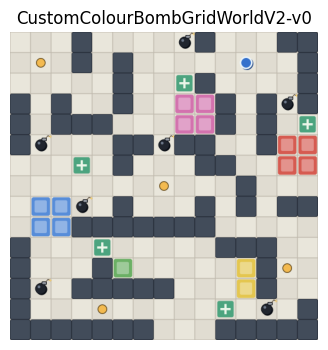

## `CustomColourBombGridWorldV3-v0` - Colour Bomb Grid World V3

A coloured-zone extension of V2. The state includes both grid position and an active colour zone, allowing richer task/specification dynamics.

| Setting | What it controls |
|---|---|
| `slip_prob` | Probability of stochastic action replacement outside safe states. |
| `n_coloured_zones` | Number of colour-zone layers in the expanded state space. |
| `start_states` | Start/restart states before zone expansion. |
| `green_states/yellow_states/red_states/blue_states/pink_states` | Colour-labelled states before zone expansion. |
| `wall_states` | Blocking states before zone expansion. |
| `bomb_states` | Unsafe/costly states before zone expansion. |
| `medic_states` | Safe states before zone expansion. |
| `render_window_size` | Pixel size used for rendering. |

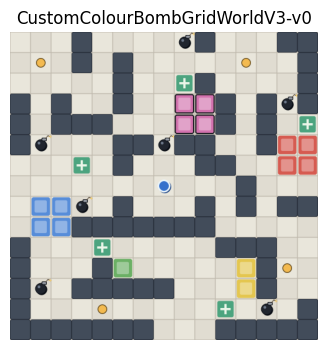

## `CustomMediaStreaming-v0` - Media Streaming

A tabular buffer-control problem. The agent chooses slow or fast streaming. Rewards penalize empty-buffer states.

| Setting | What it controls |
|---|---|
| `fast_rate` | Input probability/rate when choosing the fast action. |
| `slow_rate` | Input probability/rate when choosing the slow action. |
| `out_rate` | Playback/drain probability of the buffer. |
| `buffer_size` | Number of discrete buffer levels. |
| `start_state` | Initial buffer level; defaults to half full. |
| `render_window_size` | Pixel size used for rendering. |

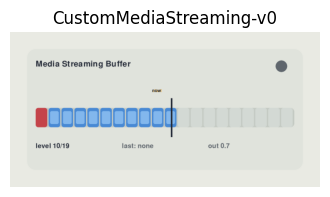

## `CustomMediaStreamingV2-v0` - Media Streaming V2

A buffer-control variant that augments the state with a count of fast actions. Unsafe labels appear when fast usage exceeds a threshold.

| Setting | What it controls |
|---|---|
| `fast_rate` | Input probability/rate for fast streaming. |
| `slow_rate` | Input probability/rate for slow streaming. |
| `out_rate` | Buffer drain probability. |
| `buffer_size` | Number of discrete buffer levels. |
| `episode_length` | Reference horizon used to derive the default fast-action threshold. |
| `c_threshold` | Maximum tolerated fast-action count before the unsafe label is reached. |
| `render_window_size` | Pixel size used for rendering. |

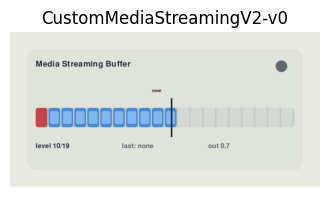

## `CustomMediaStreamingV3-v0` - Media Streaming V3

A safety-abstraction variant with dictionary observations containing danger, buffer, and time. Actions change danger according to different transition probabilities.

| Setting | What it controls |
|---|---|
| `buffer_size` | Number of buffer levels in observations and rendering. |
| `episode_length` | Maximum time index before termination. |
| `danger_threshold` | Danger level after which the unsafe label is reached. |
| `slow_danger_down_prob/slow_danger_up_prob` | Danger transition probabilities after the slow action. |
| `fast_danger_up_prob/fast_danger_down_prob` | Danger transition probabilities after the fast action. |
| `start_buffer/start_danger/start_time` | Initial buffer, danger, and time values. |
| `render_window_size` | Pixel size used for rendering. |

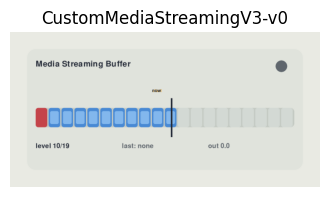

## `CustomMiniPacman-v0` - Mini Pacman

A small tabular Pacman world. The agent moves through corridors, collects food for reward, and avoids a ghost controlled by a stochastic chase policy.

| Setting | What it controls |
|---|---|
| `layout` | 2D wall/free-cell map; 1 means wall and 0 means traversable. |
| `food` | Food coordinate as (x, y). |
| `ghost_rand_prob` | How random the ghost policy is. Lower values chase more greedily. |
| `agent_start` | Agent start coordinate as (x, y). |
| `agent_term` | Terminal coordinate as (x, y). |
| `agent_direction` | Initial agent facing direction. |
| `ghost_start` | Ghost start coordinate as (x, y). |
| `ghost_direction` | Initial ghost facing direction. |
| `pacman_hat/ghost_colors` | Rendering-only appearance settings. |

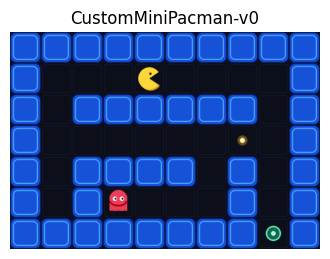

## `CustomPacman-v0` - Pacman

A larger tabular Pacman map with the same food, terminal, and ghost-chase structure as Mini Pacman, but with a much larger state space.

| Setting | What it controls |
|---|---|
| `layout` | 2D wall/free-cell map; 1 means wall and 0 means traversable. |
| `food` | Food coordinate as (x, y). |
| `ghost_rand_prob` | Ghost stochasticity; controls how deterministic the chase behavior is. |
| `agent_start` | Agent start coordinate as (x, y). |
| `agent_term` | Terminal coordinate as (x, y). |
| `agent_direction` | Initial agent facing direction. |
| `ghost_start` | Ghost start coordinate as (x, y). |
| `ghost_direction` | Initial ghost facing direction. |
| `pacman_hat/ghost_colors` | Rendering-only appearance settings. |

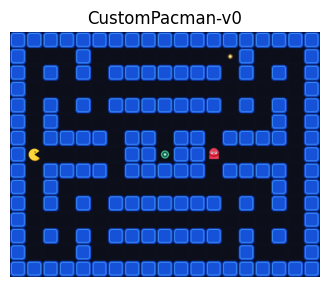

In [3]:
def settings_table(settings: dict[str, str]) -> str:
    rows = ["| Setting | What it controls |", "|---|---|"]
    for name, description in settings.items():
        rows.append(f"| `{name}` | {description} |")
    return "\n".join(rows)


def show_env_card(card: dict) -> None:
    display(Markdown(f"## `{card['id']}` - {card['title']}"))
    display(Markdown(textwrap.dedent(card["explanation"]).strip()))
    display(Markdown(settings_table(card["settings"])))

    kwargs = dict(card.get("example_kwargs", {}))
    env = make_custom_masa_env(card["id"], env_kwargs=kwargs, render_mode="rgb_array")
    try:
        obs, info = env.reset(seed=7)
        frame = env.render()
        if isinstance(frame, np.ndarray):
            plt.figure(figsize=(4.0, 4.0))
            plt.imshow(frame)
            plt.axis("off")
            plt.title(card["id"])
            plt.show()
        else:
            display(Markdown("Renderer did not return an RGB frame; falling back to ANSI."))
            env.close()
            ansi_env = make_custom_masa_env(card["id"], env_kwargs=kwargs, render_mode="ansi")
            try:
                ansi_env.reset(seed=7)
                print(ansi_env.render())
            finally:
                ansi_env.close()
    finally:
        env.close()


for card in ENV_CARDS:
    show_env_card(card)


## Example: Creating A Tweaked Environment

The same settings can be passed through `gymnasium.make`, the local factory helper, or task YAML via `env_kwargs`.

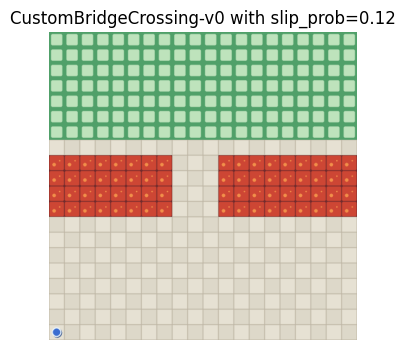

In [4]:
env = make_custom_masa_env(
    "CustomBridgeCrossing-v0",
    max_episode_steps=100,
    env_kwargs={"slip_prob": 0.12},
    render_mode="rgb_array",
)
try:
    obs, info = env.reset(seed=0)
    frame = env.render()
    plt.figure(figsize=(4, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title("CustomBridgeCrossing-v0 with slip_prob=0.12")
    plt.show()
finally:
    env.close()


## Example: CustomFrozenLake-v0

`CustomFrozenLake-v0` keeps Gymnasium FrozenLake dynamics and rendering while exposing MASA-style tabular helpers such as `get_transition_matrix()`, `label_fn(...)`, and `cost_fn(...)`.

In [ ]:
frozen_env = make_custom_masa_env(
    "CustomFrozenLake-v0",
    max_episode_steps=32,
    env_kwargs={
        "desc": ["SFFF", "FHFH", "FFFH", "HFFG"],
        "is_slippery": True,
        "success_rate": 1.0 / 3.0,
    },
    render_mode="rgb_array",
)
try:
    obs, info = frozen_env.reset(seed=0)
    frame = frozen_env.render()
    transition_matrix = frozen_env.unwrapped.get_transition_matrix()
    print("Initial observation:", obs)
    print("Initial labels:", frozen_env.unwrapped.label_fn(obs))
    print("Transition matrix shape:", transition_matrix.shape)

    plt.figure(figsize=(4, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title("CustomFrozenLake-v0")
    plt.show()
finally:
    frozen_env.close()


Equivalent task YAML shape:

```yaml
env_id: CustomBridgeCrossing-v0
max_episode_steps: 100
env_kwargs:
  slip_prob: 0.12

---
env_id: CustomFrozenLake-v0
max_episode_steps: 32
env_kwargs:
  desc:
    - SFFF
    - FHFH
    - FFFH
    - HFFG
  is_slippery: true
  success_rate: 0.3333333333333333
```